# Clustering des Prix de Véhicules

Analyse des prix neufs vs occasion pour identifier les bonnes et mauvaises affaires.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
# Chargement des données de prix neufs
df_neuf = pd.read_csv("../csv/Price_table.csv")
df_neuf.head()

,Maker,Genmodel,Genmodel_ID,Year,Entry_price
0,Abarth,124 Spider,2_1,2016,29365
1,Abarth,124 Spider,2_1,2017,26665
2,Abarth,124 Spider,2_1,2018,26665
3,Abarth,124 Spider,2_1,2019,29515
4,Abarth,500,2_2,2009,13400


In [5]:
# Chargement des données de prix occasion
df_occasion = pd.read_csv("../csv/used_cars_1M_2025.csv")
df_occasion.head()

,id,country,city,brand,model,year,mileage_km,price_usd,fuel_type,transmission,horsepower,doors,color,condition_score,days_on_market,is_electric
0,1,USA,Adamport,Chevrolet,Silverado,2011.0,185945.0,5903.0,Hybrid,Manual,486.0,3.0,Silver,7.6,285.0,0.0
1,2,France,Mahe,Toyota,Corolla,2017.0,141520.0,9277.0,Plug-in Hybrid,Automatic,473.0,4.0,Brown,4.5,34.0,0.0
2,3,Germany,Hettstedt,BMW,5 Series,2016.0,139091.0,18918.0,Gasoline,Automatic,298.0,4.0,Blue,4.6,27.0,0.0
3,4,Germany,Kulmbach,Honda,CR-V,2007.0,258093.0,5058.0,Gasoline,Automatic,99.0,5.0,White,4.6,362.0,0.0
4,5,USA,Port Cory,Hyundai,Elantra,2017.0,147560.0,16954.0,Hybrid,Automatic,236.0,5.0,Yellow,8.5,359.0,1.0


In [6]:
# Préparation des données pour la fusion
df_occasion['brand'] = df_occasion['brand'].str.strip().str.lower()
df_occasion['model'] = df_occasion['model'].str.strip().str.lower()
df_neuf['Maker'] = df_neuf['Maker'].str.strip().str.lower()
df_neuf['Genmodel'] = df_neuf['Genmodel'].str.strip().str.lower()

# Renommer pour faciliter la fusion
df_occasion_clean = df_occasion[['brand', 'model', 'year', 'price_usd']].copy()
df_neuf_clean = df_neuf[['Maker', 'Genmodel', 'Year', 'Entry_price']].copy()
df_neuf_clean.columns = ['brand', 'model', 'year', 'price_neuf']

In [7]:
# Fusion des deux datasets
df_merged = df_occasion_clean.merge(
    df_neuf_clean, 
    on=['brand', 'model', 'year'], 
    how='inner'
)

print(f"Nombre de véhicules correspondants: {len(df_merged)}")
df_merged.head()

Nombre de véhicules correspondants: 308111


,brand,model,year,price_usd,price_neuf
0,bmw,5 series,2016.0,18918.0,31060
1,honda,cr-v,2007.0,5058.0,17847
2,subaru,outback,2005.0,4477.0,19802
3,volkswagen,golf,1999.0,1777.0,11198
4,toyota,corolla,2004.0,897.0,10650


In [8]:
# Calcul du ratio prix occasion / prix neuf
df_merged['prix_ratio'] = df_merged['price_usd'] / df_merged['price_neuf']
df_merged['depreciation'] = 1 - df_merged['prix_ratio']

# Supprimer les valeurs aberrantes (ratio > 2 = véhicule occasion plus cher que neuf)
df_merged = df_merged[(df_merged['prix_ratio'] > 0) & (df_merged['prix_ratio'] <= 2)]

print(f"Nombre de véhicules après nettoyage: {len(df_merged)}")
df_merged[['brand', 'model', 'year', 'price_usd', 'price_neuf', 'prix_ratio']].head(10)

Nombre de véhicules après nettoyage: 305602


,brand,model,year,price_usd,price_neuf,prix_ratio
0,bmw,5 series,2016.0,18918.0,31060,0.609079
1,honda,cr-v,2007.0,5058.0,17847,0.283409
2,subaru,outback,2005.0,4477.0,19802,0.226088
3,volkswagen,golf,1999.0,1777.0,11198,0.158689
4,toyota,corolla,2004.0,897.0,10650,0.084225
5,honda,cr-v,2015.0,12164.0,21655,0.561718
6,audi,a6,2017.0,12164.0,32240,0.377295
7,toyota,corolla,2000.0,904.0,9815,0.092104
8,honda,accord,2003.0,3805.0,13815,0.275425
9,honda,cr-v,1999.0,1512.0,15975,0.094648


In [9]:
# Sélection des features pour le clustering
X = df_merged[['prix_ratio', 'price_usd']]
X.head()

,prix_ratio,price_usd
0,0.609079,18918.0
1,0.283409,5058.0
2,0.226088,4477.0
3,0.158689,1777.0
4,0.084225,897.0


In [10]:
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Application de KMeans avec K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

df_merged['cluster'] = labels
df_merged['cluster'].value_counts()

cluster
2    119801
4     90063
0     57450
3     28890
1      9398
Name: count, dtype: int64

In [12]:
# Analyse des clusters
cluster_stats = df_merged.groupby('cluster').agg({
    'prix_ratio': 'mean',
    'price_usd': 'mean',
    'depreciation': 'mean'
}).round(3)

cluster_stats = cluster_stats.sort_values('prix_ratio')
print("Statistiques par cluster (triées par prix_ratio):\n")
print(cluster_stats)

Statistiques par cluster (triées par prix_ratio):

         prix_ratio  price_usd  depreciation
cluster                                     
2             0.151   2682.127         0.849
4             0.344   6935.723         0.656
0             0.564  12631.162         0.436
3             0.875  19915.066         0.125
1             1.370  30952.492        -0.370


In [13]:
# Attribution des labels aux clusters
# On trie les clusters par prix_ratio croissant
# Plus le ratio est faible, meilleure est l'affaire (voiture moins chère que neuf)
cluster_order = cluster_stats.index.tolist()

cluster_labels = {
    cluster_order[0]: "Très bonne affaire",
    cluster_order[1]: "Bonne affaire",
    cluster_order[2]: "Prix du marché",
    cluster_order[3]: "Prix légèrement élevé",
    cluster_order[4]: "Mauvaise affaire"
}

df_merged['categorie'] = df_merged['cluster'].map(cluster_labels)

print("\nMapping des clusters:")
for cluster, label in cluster_labels.items():
    count = len(df_merged[df_merged['cluster'] == cluster])
    ratio = cluster_stats.loc[cluster, 'prix_ratio']
    print(f"  Cluster {cluster} ({label}): {count} véhicules, ratio moyen = {ratio:.1%}")


Mapping des clusters:
  Cluster 2 (Très bonne affaire): 119801 véhicules, ratio moyen = 15.1%
  Cluster 4 (Bonne affaire): 90063 véhicules, ratio moyen = 34.4%
  Cluster 0 (Prix du marché): 57450 véhicules, ratio moyen = 56.4%
  Cluster 3 (Prix légèrement élevé): 28890 véhicules, ratio moyen = 87.5%
  Cluster 1 (Mauvaise affaire): 9398 véhicules, ratio moyen = 137.0%


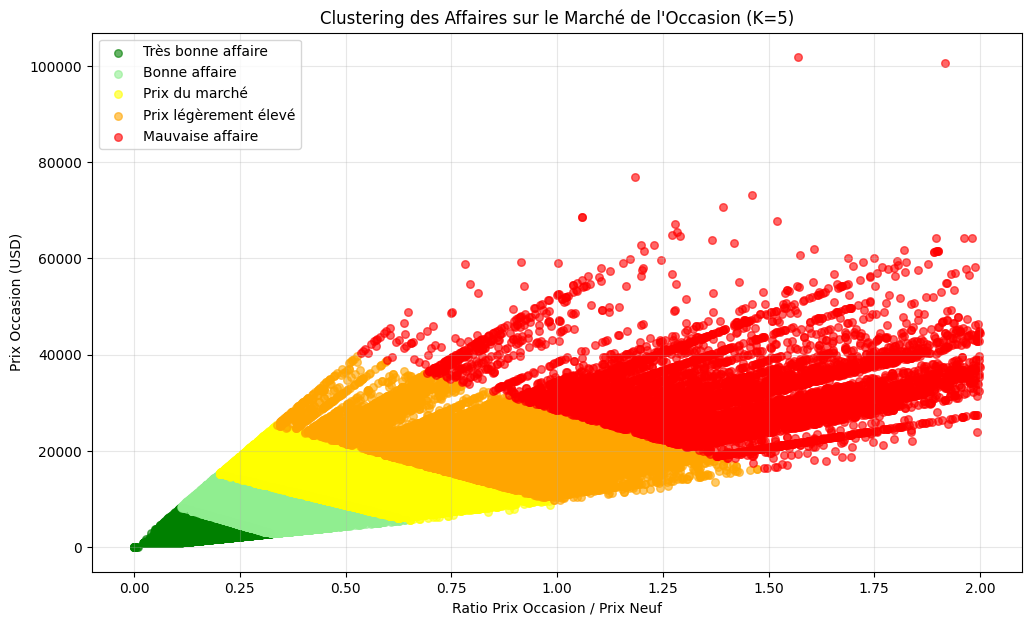

In [14]:
# Visualisation des clusters
plt.figure(figsize=(12,7))

colors = ['green', 'lightgreen', 'yellow', 'orange', 'red']
for i, (cluster, label) in enumerate(cluster_labels.items()):
    mask = df_merged['cluster'] == cluster
    plt.scatter(df_merged[mask]['prix_ratio'], 
                df_merged[mask]['price_usd'],
                label=label,
                alpha=0.6,
                s=30,
                color=colors[i])

plt.xlabel("Ratio Prix Occasion / Prix Neuf")
plt.ylabel("Prix Occasion (USD)")
plt.title("Clustering des Affaires sur le Marché de l'Occasion (K=5)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Exemples de véhicules par catégorie
print("Exemples par catégorie:\n")
for label in ["Très bonne affaire", "Bonne affaire", "Prix du marché", "Prix légèrement élevé", "Mauvaise affaire"]:
    print(f"\n{label.upper()}:")
    samples = df_merged[df_merged['categorie'] == label][['brand', 'model', 'year', 'price_usd', 'price_neuf', 'prix_ratio']].head(3)
    print(samples.to_string(index=False))
    print("-" * 80)

Exemples par catégorie:


TRÈS BONNE AFFAIRE:
     brand   model   year  price_usd  price_neuf  prix_ratio
    subaru outback 2005.0     4477.0       19802    0.226088
volkswagen    golf 1999.0     1777.0       11198    0.158689
    toyota corolla 2004.0      897.0       10650    0.084225
--------------------------------------------------------------------------------

BONNE AFFAIRE:
 brand   model   year  price_usd  price_neuf  prix_ratio
 honda    cr-v 2007.0     5058.0       17847    0.283409
 tesla model s 2016.0    13433.0       57280    0.234515
toyota    rav4 2017.0     7523.0       24150    0.311511
--------------------------------------------------------------------------------

PRIX DU MARCHÉ:
brand   model   year  price_usd  price_neuf  prix_ratio
honda    cr-v 2015.0    12164.0       21655    0.561718
 audi      a6 2017.0    12164.0       32240    0.377295
  kia sorento 2008.0    10514.0       18740    0.561046
---------------------------------------------------------------

In [16]:
# Verdict final - Statistiques globales
print("="*80)
print("VERDICT FINAL - Analyse du marché de l'occasion")
print("="*80)

for label in ["Très bonne affaire", "Bonne affaire", "Prix du marché", "Prix légèrement élevé", "Mauvaise affaire"]:
    cat_data = df_merged[df_merged['categorie'] == label]
    count = len(cat_data)
    pct = (count / len(df_merged)) * 100
    avg_ratio = cat_data['prix_ratio'].mean()
    avg_deprec = cat_data['depreciation'].mean()
    
    print(f"\n{label}:")
    print(f"  • Nombre de véhicules: {count:,} ({pct:.1f}%)")
    print(f"  • Ratio moyen: {avg_ratio:.1%} du prix neuf")
    print(f"  • Dépréciation moyenne: {avg_deprec:.1%}")
    
print("\n" + "="*80)

VERDICT FINAL - Analyse du marché de l'occasion

Très bonne affaire:
  • Nombre de véhicules: 119,801 (39.2%)
  • Ratio moyen: 15.1% du prix neuf
  • Dépréciation moyenne: 84.9%

Bonne affaire:
  • Nombre de véhicules: 90,063 (29.5%)
  • Ratio moyen: 34.4% du prix neuf
  • Dépréciation moyenne: 65.6%

Prix du marché:
  • Nombre de véhicules: 57,450 (18.8%)
  • Ratio moyen: 56.4% du prix neuf
  • Dépréciation moyenne: 43.6%

Prix légèrement élevé:
  • Nombre de véhicules: 28,890 (9.5%)
  • Ratio moyen: 87.5% du prix neuf
  • Dépréciation moyenne: 12.5%

Mauvaise affaire:
  • Nombre de véhicules: 9,398 (3.1%)
  • Ratio moyen: 137.0% du prix neuf
  • Dépréciation moyenne: -37.0%

